In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


# 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [3]:
# 2. Load Dataset
orig = pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv")
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Submission Shape:", sample_submission.shape)

train.head()

Train Shape: (439140, 16)
Test Shape: (188165, 15)
Sample Submission Shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
display(orig.info())
display(orig.describe())
display(orig.head())

print("Missing Values in Original Dataset:")
display(orig.isnull().sum().sort_values(ascending=False).head(20))

print("Duplicate Rows:", orig.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

None

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


Missing Values in Original Dataset:


Compound                  66
Driver                     0
LapNumber                  0
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

Duplicate Rows: 0


In [5]:
orig['Compound'] = orig['Compound'].fillna('Unknown')
test['Compound'] = test['Compound'].fillna('Unknown')

In [6]:
train = pd.concat([train, orig], axis=0).reset_index(drop=True)

In [7]:
train = train.drop(columns=['Normalized_TyreLife', 'id'], axis=1)

In [8]:
# 3. Dataset Overview

display(train.info())
display(train.describe())
display(train.head())

print("Missing Values in Train:")
display(train.isnull().sum().sort_values(ascending=False).head(20))

print("Duplicate Rows:", train.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540511 entries, 0 to 540510
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  540511 non-null  object 
 1   Compound                540511 non-null  object 
 2   Race                    540511 non-null  object 
 3   Year                    540511 non-null  int64  
 4   PitStop                 540511 non-null  int64  
 5   LapNumber               540511 non-null  int64  
 6   Stint                   540511 non-null  int64  
 7   TyreLife                540511 non-null  float64
 8   Position                540511 non-null  int64  
 9   LapTime (s)             540511 non-null  float64
 10  LapTime_Delta           540511 non-null  float64
 11  Cumulative_Degradation  540511 non-null  float64
 12  RaceProgress            540511 non-null  float64
 13  Position_Change         540511 non-null  float64
 14  PitNextLap          

None

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000
mean,2023.535948,0.157773,24.482301,1.837365,14.231582,9.654494,91.256021,-3.101221,-26.439742,0.355470,0.081628,0.209450
std,1.039448,0.364528,17.424550,0.955225,9.900556,5.303185,22.916342,44.233406,58.002225,0.256883,3.989509,0.406916
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.012000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,10.000000,1.000000,6.000000,5.000000,82.430000,-8.717000,-47.611500,0.141026,-1.000000,0.000000
50%,2024.000000,0.000000,21.000000,2.000000,12.000000,10.000000,90.648000,-0.226000,-21.068000,0.294872,0.000000,0.000000
75%,2024.000000,0.000000,38.000000,2.000000,20.000000,14.000000,98.632000,0.338000,-5.918000,0.541667,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,78.000000,20.000000,2526.253000,2433.472000,2412.431000,1.000000,18.000000,1.000000


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Missing Values in Train:


Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Duplicate Rows: 0


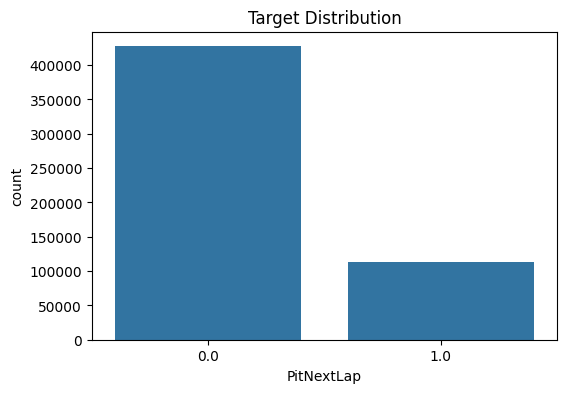

PitNextLap
0.0    0.79055
1.0    0.20945
Name: proportion, dtype: float64


In [9]:
# 4. Target Analysis

TARGET = "PitNextLap"
ID = "id"

plt.figure(figsize=(6,4))
sns.countplot(x=train[TARGET])
plt.title("Target Distribution")
plt.show()

print(train[TARGET].value_counts(normalize=True))

In [10]:
# 5. Basic EDA

num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = [c for c in num_cols if c not in [ID, TARGET]]

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 11
Categorical Columns: 3


In [11]:
# Numerical Feature Distribution
"""
for col in num_cols[:10]:
    plt.figure(figsize=(6,4))
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()"""

'\nfor col in num_cols[:10]:\n    plt.figure(figsize=(6,4))\n    sns.histplot(train[col], kde=True)\n    plt.title(f"Distribution of {col}")\n    plt.show()'

In [12]:
# Categorical Feature Countplot
"""
for col in cat_cols[:10]:
    plt.figure(figsize=(8,4))
    sns.countplot(y=train[col], order=train[col].value_counts().index[:15])
    plt.title(f"Countplot of {col}")
    plt.show()"""

'\nfor col in cat_cols[:10]:\n    plt.figure(figsize=(8,4))\n    sns.countplot(y=train[col], order=train[col].value_counts().index[:15])\n    plt.title(f"Countplot of {col}")\n    plt.show()'

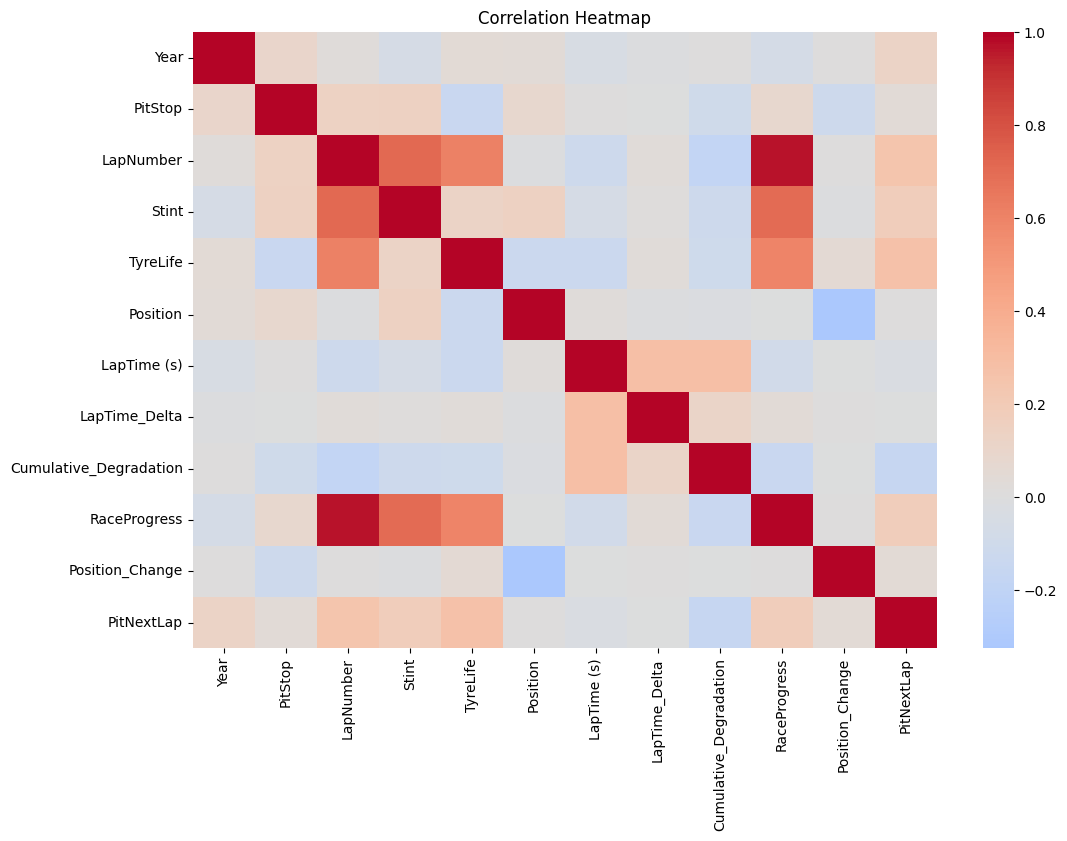

In [13]:
# Correlation Heatmap

corr_cols = num_cols + [TARGET]

plt.figure(figsize=(12,8))
sns.heatmap(train[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# =====================================
# Advanced Feature Engineering
# Combined FE Version
# =====================================

def feature_engineering(df):

    df = df.copy()

    # =====================================
    # Basic Row Statistics
    # =====================================

    numeric_cols = df.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    numeric_cols = [
        c for c in numeric_cols
        if c not in [ID, TARGET]
    ]

    if len(numeric_cols) > 0:

        df["num_mean"] = df[numeric_cols].mean(axis=1)

        df["num_std"] = df[numeric_cols].std(axis=1)

        df["num_min"] = df[numeric_cols].min(axis=1)

        df["num_max"] = df[numeric_cols].max(axis=1)

        df["num_range"] = (
            df["num_max"] - df["num_min"]
        )

    # =====================================
    # Tyre Features
    # =====================================

    if "TyreLife" in df.columns:

        df["TyreLife_sq"] = (
            df["TyreLife"] ** 2
        )

        df["TyreLife_cb"] = (
            df["TyreLife"] ** 3
        )

        df["TyreLife_log"] = np.log1p(
            df["TyreLife"]
        )

    # =====================================
    # Degradation Features
    # =====================================

    if (
        "Cumulative_Degradation" in df.columns and
        "TyreLife" in df.columns
    ):

        df["Deg_per_lap"] = (
            df["Cumulative_Degradation"] /
            (df["TyreLife"] + 1)
        )

        df["Deg_x_TyreLife"] = (
            df["Cumulative_Degradation"] *
            df["TyreLife"]
        )

        df["AbsDeg"] = (
            df["Cumulative_Degradation"].abs()
        )

    # =====================================
    # Race Progress Features
    # =====================================

    if "RaceProgress" in df.columns:

        df["Progress_sq"] = (
            df["RaceProgress"] ** 2
        )

        df["LapsRemaining"] = (
            1.0 - df["RaceProgress"]
        )

        df["IsEarlyRace"] = (
            df["RaceProgress"] < 0.25
        ).astype(int)

        df["IsMidRace"] = (
            (
                (df["RaceProgress"] >= 0.25) &
                (df["RaceProgress"] < 0.75)
            )
        ).astype(int)

        df["IsLateRace"] = (
            df["RaceProgress"] >= 0.75
        ).astype(int)

    # =====================================
    # Stint Features
    # =====================================

    if (
        "Stint" in df.columns and
        "TyreLife" in df.columns
    ):

        df["Stint_x_TyreLife"] = (
            df["Stint"] *
            df["TyreLife"]
        )

    if (
        "Stint" in df.columns and
        "RaceProgress" in df.columns
    ):

        df["Stint_x_Progress"] = (
            df["Stint"] *
            df["RaceProgress"]
        )

    # =====================================
    # Lap Features
    # =====================================

    if "LapNumber" in df.columns:

        df["LapNumber_sq"] = (
            df["LapNumber"] ** 2
        )

        df["LapNumber_log"] = np.log1p(
            df["LapNumber"]
        )

    if (
        "LapNumber" in df.columns and
        "Stint" in df.columns
    ):

        df["lap_per_stint"] = (
            df["LapNumber"] /
            (df["Stint"] + 1)
        )

    if (
        "LapNumber" in df.columns and
        "RaceProgress" in df.columns
    ):

        df["lap_progress_ratio"] = (
            df["LapNumber"] /
            (df["RaceProgress"] + 1e-6)
        )

    # =====================================
    # Tyre Ratio Features
    # =====================================

    if (
        "TyreLife" in df.columns and
        "LapNumber" in df.columns
    ):

        df["tyre_life_ratio"] = (
            df["TyreLife"] /
            (df["LapNumber"] + 1)
        )

    if (
        "tyre_life_ratio" in df.columns and
        "Cumulative_Degradation" in df.columns
    ):

        df["tyre_degradation_pressure"] = (
            df["tyre_life_ratio"] *
            df["Cumulative_Degradation"]
        )

    # =====================================
    # LapTime Features
    # =====================================

    if "LapTime (s)" in df.columns:

        df["LapTime_log"] = np.log1p(
            df["LapTime (s)"].clip(lower=0)
        )

    if "LapTime_Delta" in df.columns:

        df["DeltaAbs"] = (
            df["LapTime_Delta"].abs()
        )

        df["Delta_sq"] = (
            df["LapTime_Delta"] ** 2
        )

        df["lap_delta_sq"] = (
            df["LapTime_Delta"] ** 2
        )

    if (
        "LapTime (s)" in df.columns and
        "TyreLife" in df.columns
    ):

        df["LapTime_x_TyreLife"] = (
            df["LapTime (s)"] *
            df["TyreLife"]
        )

    if (
        "LapTime (s)" in df.columns and
        "Position" in df.columns
    ):

        df["LapTime_x_Position"] = (
            df["LapTime (s)"] *
            df["Position"]
        )

    if (
        "LapTime (s)" in df.columns and
        "Cumulative_Degradation" in df.columns
    ):

        df["laptime_degradation"] = (
            df["LapTime (s)"] *
            df["Cumulative_Degradation"]
        )

    # =====================================
    # Position Features
    # =====================================

    if "Position" in df.columns:

        df["Position_inv"] = (
            1.0 /
            (df["Position"] + 1)
        )

        df["IsLeading"] = (
            df["Position"] == 1
        ).astype(int)

        df["IsTop5"] = (
            df["Position"] <= 5
        ).astype(int)

        df["IsBack10"] = (
            df["Position"] >= 11
        ).astype(int)

        df["position_change"] = (
            df["Position"]
            .diff()
            .fillna(0)
        )

    if (
        "Position" in df.columns and
        "RaceProgress" in df.columns
    ):

        df["Position_x_Progress"] = (
            df["Position"] *
            df["RaceProgress"]
        )

    if (
        "Position" in df.columns and
        "LapNumber" in df.columns
    ):

        df["position_lap_interaction"] = (
            df["Position"] *
            df["LapNumber"]
        )

    if "Position_Change" in df.columns:

        df["PosChange_abs"] = (
            df["Position_Change"].abs()
        )

    if (
        "position_lap_interaction" in df.columns and
        "position_change" in df.columns
    ):

        df["position_race_dynamics"] = (
            df["position_lap_interaction"] +
            df["position_change"]
        )

    # =====================================
    # Cross Features
    # =====================================

    if (
        "TyreLife" in df.columns and
        "LapTime_Delta" in df.columns
    ):

        df["TyreLife_x_Delta"] = (
            df["TyreLife"] *
            df["LapTime_Delta"]
        )

    if (
        "RaceProgress" in df.columns and
        "TyreLife" in df.columns
    ):

        df["Progress_x_TyreLife"] = (
            df["RaceProgress"] *
            df["TyreLife"]
        )

    if (
        "RaceProgress" in df.columns and
        "Stint" in df.columns
    ):

        df["Progress_x_Stint"] = (
            df["RaceProgress"] *
            df["Stint"]
        )

    if (
        "Cumulative_Degradation" in df.columns and
        "RaceProgress" in df.columns
    ):

        df["Deg_x_Progress"] = (
            df["Cumulative_Degradation"] *
            df["RaceProgress"]
        )

    # =====================================
    # Compound Features
    # =====================================

    if "Compound" in df.columns:

        df["Compound_SOFT"] = (
            df["Compound"] == "SOFT"
        ).astype(int)

        df["Compound_HARD"] = (
            df["Compound"] == "HARD"
        ).astype(int)

        df["Compound_WET"] = (
            df["Compound"].isin(
                ["WET", "INTERMEDIATE"]
            )
        ).astype(int)

    # =====================================
    # Year Features
    # =====================================

    if "Year" in df.columns:

        for y in [2022, 2023, 2024, 2025]:

            df[f"Year_{y}"] = (
                df["Year"] == y
            ).astype(int)

    return df


# =====================================
# Apply Feature Engineering
# =====================================

train_fe = feature_engineering(train)

test_fe = feature_engineering(test)

print(train_fe.shape)
print(test_fe.shape)

(540511, 66)
(188165, 66)


In [15]:
train_fe.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap', 'num_mean', 'num_std', 'num_min', 'num_max', 'num_range',
       'TyreLife_sq', 'TyreLife_cb', 'TyreLife_log', 'Deg_per_lap',
       'Deg_x_TyreLife', 'AbsDeg', 'Progress_sq', 'LapsRemaining',
       'IsEarlyRace', 'IsMidRace', 'IsLateRace', 'Stint_x_TyreLife',
       'Stint_x_Progress', 'LapNumber_sq', 'LapNumber_log', 'lap_per_stint',
       'lap_progress_ratio', 'tyre_life_ratio', 'tyre_degradation_pressure',
       'LapTime_log', 'DeltaAbs', 'Delta_sq', 'lap_delta_sq',
       'LapTime_x_TyreLife', 'LapTime_x_Position', 'laptime_degradation',
       'Position_inv', 'IsLeading', 'IsTop5', 'IsBack10', 'position_change',
       'Position_x_Progress', 'position_lap_interaction', 'PosChange_abs',
       'position_race_dynamics', 'TyreLife_x_Delta', 'Progress_x_T

In [16]:
# 7. Preprocessing

X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET]
X_test = test_fe.copy()

test_ids = X_test[ID]

#X = X.drop(columns=[ID])
X_test = X_test.drop(columns=[ID])

# Combine train and test for consistent encoding
combined = pd.concat([X, X_test], axis=0)

cat_cols = combined.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in cat_cols:
    combined[col] = combined[col].astype(str).fillna("missing")
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

# Fill missing numeric values
combined = combined.fillna(combined.median(numeric_only=True))

X = combined.iloc[:len(X), :]
X_test = combined.iloc[len(X):, :]

print("Final Train Shape:", X.shape)
print("Final Test Shape:", X_test.shape)

Final Train Shape: (540511, 65)
Final Test Shape: (188165, 65)


In [17]:
# 8. Validation Strategy

N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=777)

In [18]:
# 9. Model Training Function

import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import numpy as np

def train_model(model, X, y, X_test, model_name):

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        print(f"\n===== {model_name} | Fold {fold+1} =====")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        # -----------------------------
        # LightGBM
        # -----------------------------
        if model_name == "LightGBM":

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_valid, y_valid)],
                callbacks=[
                    lgb.early_stopping(200),
                    lgb.log_evaluation(200)
                ]
            )

        # -----------------------------
        # XGBoost
        # -----------------------------
        elif model_name == "XGBoost":

            model.fit(
                X_train,
                y_train,
                eval_set=[(X_valid, y_valid)],
                verbose=200
            )

        # -----------------------------
        # CatBoost
        # -----------------------------
        else:

            model.fit(
                X_train,
                y_train,
                eval_set=(X_valid, y_valid),
                use_best_model=True,
                verbose=200
            )

        # Predictions
        valid_pred = model.predict_proba(X_valid)[:, 1]
        test_pred = model.predict_proba(X_test)[:, 1]

        # Store OOF
        oof_preds[valid_idx] = valid_pred

        # Average Test Predictions
        test_preds += test_pred / N_SPLITS

        # Fold Score
        auc = roc_auc_score(y_valid, valid_pred)
        scores.append(auc)

        print(f"Fold {fold+1} ROC AUC: {auc:.5f}")

    # Final CV Score
    mean_auc = np.mean(scores)

    print(f"\n{model_name} Mean ROC AUC: {mean_auc:.5f}")

    return oof_preds, test_preds, mean_auc

In [19]:
# 10. CatBoost Model
cat_model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.02,
    depth=8,
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_strength=1.5,
    border_count=254,

    loss_function="Logloss",
    eval_metric="AUC",

    bootstrap_type="Bayesian",

    random_seed=777,
    verbose=200,

    task_type='GPU',
    use_best_model=True
)

cat_oof, cat_test, cat_score = train_model(
    cat_model, X, y, X_test, "CatBoost"
)


===== CatBoost | Fold 1 =====


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9136882	best: 0.9136882 (0)	total: 463ms	remaining: 38m 35s
200:	test: 0.9360448	best: 0.9360448 (200)	total: 4.05s	remaining: 1m 36s
400:	test: 0.9419543	best: 0.9419543 (400)	total: 7.6s	remaining: 1m 27s
600:	test: 0.9452323	best: 0.9452323 (600)	total: 11.1s	remaining: 1m 21s
800:	test: 0.9474587	best: 0.9474587 (800)	total: 14.6s	remaining: 1m 16s
1000:	test: 0.9489059	best: 0.9489059 (1000)	total: 17.9s	remaining: 1m 11s
1200:	test: 0.9500784	best: 0.9500784 (1200)	total: 21.2s	remaining: 1m 6s
1400:	test: 0.9510312	best: 0.9510312 (1400)	total: 24.4s	remaining: 1m 2s
1600:	test: 0.9518564	best: 0.9518564 (1600)	total: 27.9s	remaining: 59.1s
1800:	test: 0.9524906	best: 0.9524906 (1800)	total: 31.3s	remaining: 55.6s
2000:	test: 0.9530820	best: 0.9530820 (2000)	total: 34.7s	remaining: 51.9s
2200:	test: 0.9535768	best: 0.9535768 (2200)	total: 38.2s	remaining: 48.5s
2400:	test: 0.9540147	best: 0.9540147 (2400)	total: 41.6s	remaining: 45.1s
2600:	test: 0.9544333	best: 0.954

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9139872	best: 0.9139872 (0)	total: 31.9ms	remaining: 2m 39s
200:	test: 0.9360402	best: 0.9360402 (200)	total: 3.58s	remaining: 1m 25s
400:	test: 0.9418049	best: 0.9418049 (400)	total: 7.06s	remaining: 1m 21s
600:	test: 0.9449719	best: 0.9449719 (600)	total: 10.5s	remaining: 1m 16s
800:	test: 0.9471754	best: 0.9471754 (800)	total: 14s	remaining: 1m 13s
1000:	test: 0.9487140	best: 0.9487140 (1000)	total: 17.4s	remaining: 1m 9s
1200:	test: 0.9499193	best: 0.9499193 (1200)	total: 20.6s	remaining: 1m 5s
1400:	test: 0.9508241	best: 0.9508241 (1400)	total: 23.8s	remaining: 1m 1s
1600:	test: 0.9516498	best: 0.9516498 (1600)	total: 27.1s	remaining: 57.6s
1800:	test: 0.9522873	best: 0.9522873 (1800)	total: 30.4s	remaining: 54s
2000:	test: 0.9529135	best: 0.9529135 (2000)	total: 33.6s	remaining: 50.4s
2200:	test: 0.9534628	best: 0.9534628 (2200)	total: 36.9s	remaining: 46.9s
2400:	test: 0.9539023	best: 0.9539023 (2400)	total: 40.4s	remaining: 43.7s
2600:	test: 0.9543231	best: 0.9543231

...

0:	test: 0.9141311	best: 0.9141311 (0)	total: 31.4ms	remaining: 2m 36s
200:	test: 0.9360526	best: 0.9360526 (200)	total: 3.69s	remaining: 1m 28s
400:	test: 0.9416988	best: 0.9416988 (400)	total: 6.92s	remaining: 1m 19s
600:	test: 0.9450365	best: 0.9450365 (600)	total: 10.1s	remaining: 1m 14s
800:	test: 0.9471323	best: 0.9471323 (800)	total: 13.5s	remaining: 1m 10s
1000:	test: 0.9487552	best: 0.9487552 (1000)	total: 16.7s	remaining: 1m 6s
1200:	test: 0.9499684	best: 0.9499684 (1200)	total: 20s	remaining: 1m 3s
1400:	test: 0.9509329	best: 0.9509329 (1400)	total: 23.4s	remaining: 1m
1600:	test: 0.9517291	best: 0.9517291 (1600)	total: 26.8s	remaining: 56.9s
1800:	test: 0.9524241	best: 0.9524241 (1800)	total: 30.3s	remaining: 53.8s
2000:	test: 0.9529762	best: 0.9529762 (2000)	total: 33.7s	remaining: 50.5s
2200:	test: 0.9534986	best: 0.9534986 (2200)	total: 37.2s	remaining: 47.3s
2400:	test: 0.9539674	best: 0.9539674 (2400)	total: 40.7s	remaining: 44s
2600:	test: 0.9543346	best: 0.9543346 (2

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9132793	best: 0.9132793 (0)	total: 32.3ms	remaining: 2m 41s
200:	test: 0.9349725	best: 0.9349725 (200)	total: 3.59s	remaining: 1m 25s
400:	test: 0.9406981	best: 0.9406981 (400)	total: 6.98s	remaining: 1m 20s
600:	test: 0.9439433	best: 0.9439433 (600)	total: 10.3s	remaining: 1m 15s
800:	test: 0.9460843	best: 0.9460843 (800)	total: 13.6s	remaining: 1m 11s
1000:	test: 0.9476789	best: 0.9476789 (1000)	total: 17s	remaining: 1m 7s
1200:	test: 0.9488523	best: 0.9488523 (1200)	total: 20.4s	remaining: 1m 4s
1400:	test: 0.9498243	best: 0.9498243 (1400)	total: 23.8s	remaining: 1m 1s
1600:	test: 0.9506394	best: 0.9506394 (1600)	total: 27.3s	remaining: 58s
1800:	test: 0.9513414	best: 0.9513414 (1800)	total: 30.8s	remaining: 54.6s
2000:	test: 0.9519537	best: 0.9519537 (2000)	total: 34.2s	remaining: 51.3s
2200:	test: 0.9525033	best: 0.9525033 (2200)	total: 37.7s	remaining: 47.9s
2400:	test: 0.9529708	best: 0.9529708 (2400)	total: 41.2s	remaining: 44.6s
2600:	test: 0.9533269	best: 0.9533269

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9131323	best: 0.9131323 (0)	total: 31.5ms	remaining: 2m 37s
200:	test: 0.9351066	best: 0.9351066 (200)	total: 3.61s	remaining: 1m 26s
400:	test: 0.9410843	best: 0.9410843 (400)	total: 6.87s	remaining: 1m 18s
600:	test: 0.9443614	best: 0.9443614 (600)	total: 10.1s	remaining: 1m 13s
800:	test: 0.9465951	best: 0.9465951 (800)	total: 13.3s	remaining: 1m 9s
1000:	test: 0.9481471	best: 0.9481471 (1000)	total: 16.6s	remaining: 1m 6s
1200:	test: 0.9494575	best: 0.9494575 (1200)	total: 19.8s	remaining: 1m 2s
1400:	test: 0.9504074	best: 0.9504074 (1400)	total: 23s	remaining: 59.2s
1600:	test: 0.9512654	best: 0.9512654 (1600)	total: 26.3s	remaining: 55.8s
1800:	test: 0.9520311	best: 0.9520311 (1800)	total: 29.7s	remaining: 52.8s
2000:	test: 0.9526137	best: 0.9526137 (2000)	total: 33.1s	remaining: 49.6s
2200:	test: 0.9531376	best: 0.9531376 (2200)	total: 36.5s	remaining: 46.4s
2400:	test: 0.9536112	best: 0.9536112 (2400)	total: 39.7s	remaining: 43s
2600:	test: 0.9539878	best: 0.9539878 

In [20]:
# 11. LightGBM Model

lgbm_model = LGBMClassifier(
    n_estimators=5000,
    learning_rate=0.02,

    max_depth=-1,
    num_leaves=63,

    min_child_samples=40,
    min_split_gain=0.01,

    subsample=0.85,
    subsample_freq=1,

    colsample_bytree=0.75,

    reg_alpha=0.5,
    reg_lambda=1.5,

    objective="binary",
    metric="auc",

    random_state=777,
    device_type='gpu',
    early_stopping_rounds=200
)
lgbm_oof, lgbm_test, lgbm_score = train_model(
    lgbm_model, X, y, X_test, "LightGBM"
)


===== LightGBM | Fold 1 =====
[LightGBM] [Warning] early_stopping_round is set=200, early_stopping_rounds=200 will be ignored. Current value: early_stopping_round=200
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 101889, number of negative: 384570
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9267
[LightGBM] [Info] Number of data points in the train set: 486459, number of used features: 65
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 54 dense feature groups (25.98 MB) transferred to GPU in 0.019410 secs. 1 sparse feature groups
[LightGBM] [Warning] early_stopping_round is set=200, early_stopping_rounds=200 will be ignored. Current value: early_stopping_round=200
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.209450 -> initscore=-1.328242
[LightGBM] [Info] Start training from score -1.328242
Training until validation scores don't improve for 200 rounds
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.944106
[400]	valid_0's auc: 0.949544
[600]	valid_0's auc: 0.952088
[800]	valid_0's auc: 0.953731
[1000]	valid_0's auc: 0.954878
[1200]	valid_0's auc: 0.955728
[1400]	valid_0's auc: 0.956406
[1600]	valid_0's auc: 0.956953
[1800]	valid_0's auc: 0.957384
[2000]	valid_0's auc: 0.957789
[2200]	va

In [21]:
# 12. XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.02,

    max_depth=8,
    min_child_weight=3,

    subsample=0.85,
    colsample_bytree=0.75,

    gamma=0.1,

    reg_alpha=0.5,
    reg_lambda=2,

    eval_metric="auc",

    random_state=777,

    tree_method="hist",
    device='cuda',
    early_stopping_rounds=200
)
xgb_oof, xgb_test, xgb_score = train_model(
    xgb_model, X, y, X_test, "XGBoost"
)


===== XGBoost | Fold 1 =====
[0]	validation_0-auc:0.92326
[200]	validation_0-auc:0.94379
[400]	validation_0-auc:0.94983
[600]	validation_0-auc:0.95317
[800]	validation_0-auc:0.95502
[1000]	validation_0-auc:0.95626
[1200]	validation_0-auc:0.95706
[1400]	validation_0-auc:0.95771
[1600]	validation_0-auc:0.95824
[1800]	validation_0-auc:0.95857
[2000]	validation_0-auc:0.95886
[2200]	validation_0-auc:0.95910
[2400]	validation_0-auc:0.95931
[2600]	validation_0-auc:0.95945
[2800]	validation_0-auc:0.95959
[3000]	validation_0-auc:0.95969
[3200]	validation_0-auc:0.95981
[3400]	validation_0-auc:0.95988
[3600]	validation_0-auc:0.95996
[3800]	validation_0-auc:0.96001
[4000]	validation_0-auc:0.96006
[4200]	validation_0-auc:0.96011
[4400]	validation_0-auc:0.96014
[4600]	validation_0-auc:0.96015
[4678]	validation_0-auc:0.96015
Fold 1 ROC AUC: 0.96015

===== XGBoost | Fold 2 =====
[0]	validation_0-auc:0.92296
[200]	validation_0-auc:0.94363
[400]	validation_0-auc:0.94976
[600]	validation_0-auc:0.95270
[

In [22]:
# 13. Model Comparison

model_scores = pd.DataFrame({
    "Model": ["CatBoost", "LightGBM", "XGBoost"],
    "CV ROC AUC": [cat_score, lgbm_score, xgb_score]
})

model_scores.sort_values("CV ROC AUC", ascending=False)

,Model,CV ROC AUC
2,XGBoost,0.960112
1,LightGBM,0.959851
0,CatBoost,0.956779


In [23]:
# 14. Ensemble
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score

# -----------------------------
# OOF Predictions Matrix
# -----------------------------
oof_matrix = np.vstack([
    cat_oof,
    lgbm_oof,
    xgb_oof
]).T

# -----------------------------
# Objective Function
# -----------------------------
def objective(weights):

    weights = np.array(weights)

    ensemble_pred = np.dot(oof_matrix, weights)

    score = roc_auc_score(y, ensemble_pred)

    return -score   # minimize negative AUC


# -----------------------------
# Initial Weights
# -----------------------------
initial_weights = [0.33, 0.33, 0.34]

# -----------------------------
# Constraints
# -----------------------------
constraints = {
    'type': 'eq',
    'fun': lambda w: 1 - sum(w)
}

bounds = [(0, 1)] * 3

# -----------------------------
# Optimize
# -----------------------------
result = minimize(
    objective,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# -----------------------------
# Best Weights
# -----------------------------
best_weights = result.x

print("\nBest Weights:")
print(f"CatBoost : {best_weights[0]:.4f}")
print(f"LightGBM : {best_weights[1]:.4f}")
print(f"XGBoost  : {best_weights[2]:.4f}")

# -----------------------------
# Final Ensemble
# -----------------------------
ensemble_oof = np.dot(oof_matrix, best_weights)

ensemble_test = (
    best_weights[0] * cat_test +
    best_weights[1] * lgbm_test +
    best_weights[2] * xgb_test
)

# -----------------------------
# Final Score
# -----------------------------
ensemble_score = roc_auc_score(y, ensemble_oof)

print(f"\nOptimized Ensemble ROC AUC: {ensemble_score:.6f}")


Best Weights:
CatBoost : 0.2567
LightGBM : 0.3906
XGBoost  : 0.3528

Optimized Ensemble ROC AUC: 0.959974


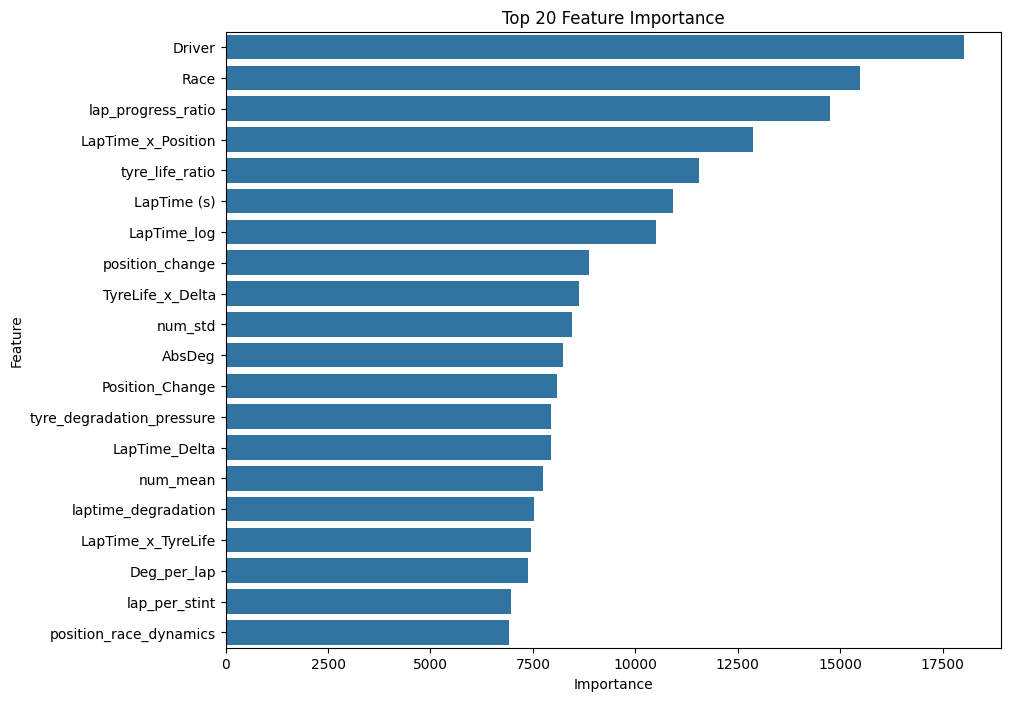

,Feature,Importance
0,Driver,18016
2,Race,15486
35,lap_progress_ratio,14744
43,LapTime_x_Position,12874
36,tyre_life_ratio,11549
9,LapTime (s),10908
38,LapTime_log,10515
49,position_change,8877
54,TyreLife_x_Delta,8635
15,num_std,8455


In [24]:
# 15. Feature Importance using LightGBM

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importance")
plt.show()

feature_importance.head(20)

In [25]:
# 16. Create Submission File

submission = pd.DataFrame({
    ID: test_ids,
    TARGET: ensemble_test
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,PitNextLap
0,439140,0.005606
1,439141,0.006168
2,439142,0.002741
3,439143,0.222728
4,439144,0.898545


In [26]:
# 17. Conclusion

print("Final CV Scores")
print(model_scores)
print("\nEnsemble CV ROC AUC:", ensemble_score)
print("\nSubmission file created: submission.csv")

Final CV Scores
      Model  CV ROC AUC
0  CatBoost    0.956779
1  LightGBM    0.959851
2   XGBoost    0.960112

Ensemble CV ROC AUC: 0.9599738376177831

Submission file created: submission.csv
